In [1]:
"""
Step 1 — Geocode 'Project Site Location' and save results to CSV.
Requirements:
    pip install pandas openpyxl geopy tqdm
"""
import os, re, json
import numpy as np
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from tqdm import tqdm

BASE_DIR   = "/Users/shirley/Desktop/forest restoration/forest_credit/data"
DATA_PATH  = os.path.join(BASE_DIR, "Voluntary-Registry-Offsets-Database--v2025-12-year-end.xlsx")
CACHE_FILE = os.path.join(BASE_DIR, "geocode_cache.json")
OUT_CSV    = os.path.join(BASE_DIR, "forest_luc_geocoded.csv")

# ── 1. Load & filter ──────────────────────────────────────────────────────────
print("Loading Excel …")
df = pd.read_excel(DATA_PATH, sheet_name="PROJECTS", header=3)
df.columns = [
    re.sub(r"\s+", "_", str(c).replace("\n", " ").replace("\r", " ").strip())
    for c in df.columns
]
df_luc = df[df["Scope"] == "Forestry & Land Use"].copy()
print(f"  Forestry & Land Use projects: {len(df_luc)}")

# ── 2. 构建 fallback 查询字符串 ───────────────────────────────────────────────
def extract_location_from_developer(dev_str):
    """从 Project Developer 字段里提取括号内或逗号后的地名片段"""
    if pd.isna(dev_str):
        return None
    # 括号内内容，如 "Evergreen Ltd (Kenya)" → "Kenya"
    m = re.search(r"\(([^)]+)\)", str(dev_str))
    if m:
        return m.group(1).strip()
    return None

def build_query(row):
    """
    优先级：
      1. Project_Site_Location（非空）
      2. Country + 从 Project_Developer 提取的地名
      3. 仅 Country（模糊兜底）
    返回 (query_string, source_label)
    """
    site = row.get("Project_Site_Location")
    country = row.get("Country")          # 根据实际列名调整
    developer = row.get("Project_Developer")  # 根据实际列名调整

    if pd.notna(site) and str(site).strip():
        return str(site).strip(), "site"

    dev_loc = extract_location_from_developer(developer)

    if pd.notna(country) and str(country).strip():
        if dev_loc:
            return f"{dev_loc}, {country}".strip(), "developer+country"
        return str(country).strip(), "country"

    return None, "unknown"

df_luc[["geo_query", "geo_source"]] = df_luc.apply(
    lambda r: pd.Series(build_query(r)), axis=1
)

missing_query = df_luc["geo_query"].isna().sum()
print(f"  有效查询: {df_luc['geo_query'].notna().sum()} / {len(df_luc)}")
print(f"  无法构建查询（跳过）: {missing_query}")
print(f"  来源分布:\n{df_luc['geo_source'].value_counts().to_string()}")

# ── 3. Geocode ────────────────────────────────────────────────────────────────
if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE, "r", encoding="utf-8") as f:
        cache = json.load(f)
else:
    cache = {}

geolocator = Nominatim(user_agent="forest_credit_mapper_v1", timeout=10)
geocode    = RateLimiter(geolocator.geocode, min_delay_seconds=1.1)

queries = df_luc["geo_query"].dropna().tolist()
print(f"\n  开始 geocoding，共 {len(queries)} 条（含重复，缓存自动跳过）…")

new_hits = 0
for q in tqdm(queries, desc="Geocoding"):
    if q in cache:
        continue
    try:
        result = geocode(q, language="en")
        cache[q] = [result.latitude, result.longitude] if result else None
    except Exception:
        cache[q] = None
    new_hits += 1

if new_hits:
    with open(CACHE_FILE, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False, indent=2)
    print(f"  新增缓存 {new_hits} 条 → {CACHE_FILE}")

# ── 4. 附加坐标 & 保存 ────────────────────────────────────────────────────────
df_luc["lat"] = df_luc["geo_query"].map(
    lambda q: cache[q][0] if (pd.notna(q) and cache.get(q)) else np.nan
)
df_luc["lon"] = df_luc["geo_query"].map(
    lambda q: cache[q][1] if (pd.notna(q) and cache.get(q)) else np.nan
)

df_out = df_luc.dropna(subset=["lat", "lon"])
df_out.to_csv(OUT_CSV, index=False)

print(f"\n✓ 最终有坐标: {len(df_out)} / {len(df_luc)} 个项目")
print(f"  坐标来源:\n{df_out['geo_source'].value_counts().to_string()}")
print(f"  已保存 → {OUT_CSV}")

Loading Excel …
  Forestry & Land Use projects: 2352
  有效查询: 2352 / 2352
  无法构建查询（跳过）: 0
  来源分布:
geo_source
country              1285
site                  992
developer+country      75

  开始 geocoding，共 2352 条（含重复，缓存自动跳过）…


Geocoding: 100%|██████████| 2352/2352 [02:54<00:00, 13.50it/s]

  新增缓存 158 条 → /Users/shirley/Desktop/forest restoration/forest_credit/data/geocode_cache.json

✓ 最终有坐标: 1982 / 2352 个项目
  坐标来源:
geo_source
country              1285
site                  654
developer+country      43
  已保存 → /Users/shirley/Desktop/forest restoration/forest_credit/data/forest_luc_geocoded.csv


Plotting 1982 projects …
✓ 已保存 → /Users/shirley/Desktop/forest restoration/forest_credit/data/forest_projects_world_map.png


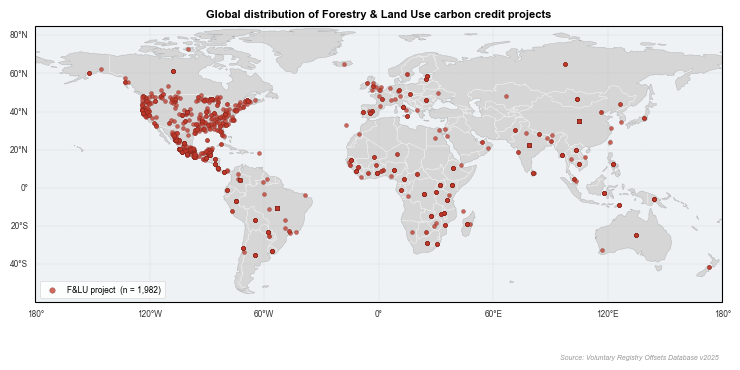

In [2]:
"""
Step 2 — plot geocoded projects on world map and save as PNG/SVG.
Requirements:      
    pip install cartopy pandas matplotlib
"""

!pip install cartopy pandas matplotlib

import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ── Config ────────────────────────────────────────────────────────────────────
BASE_DIR = "/Users/shirley/Desktop/forest restoration/forest_credit/data"
IN_CSV   = os.path.join(BASE_DIR, "forest_luc_geocoded.csv")
OUT_PNG  = os.path.join(BASE_DIR, "forest_projects_world_map.png")

# ── Science 字体风格 ──────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    "font.family"    : "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size"      : 7,
    "pdf.fonttype"   : 42,
    "ps.fonttype"    : 42,
})

# ── 颜色 ──────────────────────────────────────────────────────────────────────
LAND_COLOR   = "#D6D6D6"   # 浅灰陆地
OCEAN_COLOR  = "#EEF2F5"   # 极淡蓝海洋
BORDER_COLOR = "#FFFFFF"   # 白色国界
COAST_COLOR  = "#AAAAAA"   # 海岸线
DOT_COLOR    = "#C0392B"   # 项目点
DOT_EDGE     = "#7B241C"

# ── 读数据 ────────────────────────────────────────────────────────────────────
df = pd.read_csv(IN_CSV)
lons = df["lon"].values
lats = df["lat"].values
print(f"Plotting {len(df)} projects …")

# ── 绘图 ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(
    figsize=(7.2, 4.0),
    subplot_kw={"projection": ccrs.PlateCarree()}   # 等经纬度投影
)
fig.patch.set_facecolor("white")
ax.set_facecolor(OCEAN_COLOR)

# 内置底图要素（scale='110m' 最轻量）
ax.add_feature(cfeature.LAND.with_scale("110m"),
               facecolor=LAND_COLOR, zorder=1)
ax.add_feature(cfeature.OCEAN.with_scale("110m"),
               facecolor=OCEAN_COLOR, zorder=1)
ax.add_feature(cfeature.BORDERS.with_scale("110m"),
               edgecolor=BORDER_COLOR, linewidth=0.3, zorder=2)
ax.add_feature(cfeature.COASTLINE.with_scale("110m"),
               edgecolor=COAST_COLOR, linewidth=0.3, zorder=2)

# 项目点
ax.scatter(
    lons, lats,
    s=8,
    color=DOT_COLOR,
    edgecolors=DOT_EDGE,
    linewidths=0.3,
    alpha=0.75,
    transform=ccrs.PlateCarree(),
    zorder=4,
    label=f"F&LU project  (n = {len(df):,})",
    rasterized=True,
)

# 范围 & 网格线
ax.set_extent([-180, 180, -60, 85], crs=ccrs.PlateCarree())
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.25, color="#BBBBBB",
    linestyle="--", alpha=0.7,
    zorder=0,
)
gl.top_labels    = False
gl.right_labels  = False
gl.xlabel_style  = {"fontsize": 6, "color": "#333333"}
gl.ylabel_style  = {"fontsize": 6, "color": "#333333"}

# 标题 & 图例
ax.set_title(
    "Global distribution of Forestry & Land Use carbon credit projects",
    fontsize=8, fontweight="bold", pad=6,
)
ax.legend(
    loc="lower left", fontsize=6, frameon=True,
    framealpha=0.88, edgecolor="#CCCCCC",
    markerscale=1.4, borderpad=0.5,
).get_frame().set_linewidth(0.4)

fig.text(0.99, 0.01, "Source: Voluntary Registry Offsets Database v2025",
         ha="right", va="bottom", fontsize=5, color="#999999", style="italic")

plt.tight_layout(pad=0.4)
fig.savefig(OUT_PNG, dpi=400, bbox_inches="tight", facecolor="white")
print(f"✓ 已保存 → {OUT_PNG}")
plt.show()